#**Laboratorio 08**

# **Cluster**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [2]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


**Normalizar datos**

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Numéricas
df_num = df.select_dtypes(include=np.number)
df_num = df_num.fillna(df_num.mean())

# Escalado
scaler = MinMaxScaler()

df_num_normalizado = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=df_num.columns
)

In [6]:
df_cat = df.select_dtypes(exclude=np.number)

df_cat_encoded = pd.get_dummies(df_cat)

In [3]:
# Seleccionar variables categóricas
df_cat = df.select_dtypes(exclude=np.number)

# Transformación a variables dummy (one-hot encoding)
df_cat_encoded = pd.get_dummies(df_cat)

# Ver resultado
df_cat_encoded.head()

,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,clase_tipo_Furgoneta,clase_tipo_Vehículos Especiales,traccion_tipo_cuatro,traccion_tipo_dos,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,False,False,False,False,False,False,False,True,False,True,...,True,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False
2,False,False,False,False,False,False,False,True,False,True,...,True,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False
4,False,False,False,True,False,False,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [7]:
df_procesado = pd.concat([df_num_normalizado, df_cat_encoded], axis=1)

df_procesado.head()

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,0.000000,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.029412,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,0.029412,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.088235,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


**Realizar ajuste mediante kmeans**

In [8]:
from sklearn.cluster import KMeans

# Modelo KMeans con 8 clusters
kmeans = KMeans(n_clusters=8, random_state=42)

# Ajuste del modelo
kmeans.fit(df_procesado)

KMeans(random_state=42)

In [9]:
df_procesado["cluster"] = kmeans.labels_

df_procesado.head()

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo,cluster
0,0.000000,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,6
1,0.000000,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,4
2,0.029412,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,6
3,0.029412,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,4
4,0.088235,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,6


In [10]:
centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df_procesado.drop(columns=["cluster"]).columns
)

centroides

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.374994,0.314506,0.244536,0.354640,0.281407,2.041199e-01,0.064045,0.004120,0.080524,0.494382,...,1.693090e-15,1.647940e-02,9.801498e-01,8.965051e-15,3.370787e-03,2.247191e-02,7.216450e-16,9.775281e-01,4.551914e-15,-1.196265e-14
1,0.695630,0.178857,0.150271,0.240158,0.156818,1.129652e-14,0.110562,0.027836,0.182362,0.547867,...,7.660539e-15,-1.265654e-14,2.601457e-04,1.321165e-14,9.997399e-01,1.060263e-14,1.742976e-02,-1.082467e-14,-9.325873e-15,9.825702e-01
2,0.440116,0.361599,0.287553,0.354467,0.281434,8.043324e-02,0.090732,0.128551,0.203125,0.297585,...,8.877841e-04,3.142756e-02,9.621804e-01,3.551136e-04,5.149148e-03,1.420455e-02,7.102273e-04,9.850852e-01,-1.196265e-14,-8.354428e-15
3,0.523869,0.250495,0.195088,0.304375,0.226729,6.144330e-02,0.095395,0.045636,0.153402,0.450172,...,-1.199041e-14,9.806186e-01,-2.603473e-14,-9.048318e-15,1.938144e-02,-8.743006e-15,9.989003e-01,5.498282e-04,7.216450e-15,5.498282e-04
4,0.412004,0.576146,0.420130,0.506937,0.449663,3.338947e-01,0.003789,0.035649,0.038596,0.138667,...,4.028070e-02,-1.662559e-14,8.982456e-03,9.507368e-01,-6.716849e-15,9.824561e-04,-3.144707e-14,-1.315614e-14,9.990175e-01,1.193490e-14
5,0.438752,0.159481,0.141102,0.242174,0.156452,1.642996e-02,0.125035,0.006405,0.092453,0.710387,...,6.716849e-15,-1.201816e-14,1.709743e-14,1.254552e-14,1.000000e+00,9.631185e-15,2.784740e-03,-1.043610e-14,-7.077672e-15,9.972153e-01
6,0.476203,0.446766,0.325461,0.410605,0.344917,3.053603e-01,0.017575,0.039543,0.048770,0.154657,...,9.872583e-01,-1.398881e-14,1.186292e-02,8.787346e-04,-6.550316e-15,9.925308e-01,6.590510e-04,-1.160183e-14,6.810193e-03,-1.745826e-14
7,0.723876,0.352314,0.282860,0.352799,0.279757,7.897241e-02,0.083730,0.098002,0.121789,0.184110,...,9.514748e-04,6.327307e-02,9.162702e-01,5.218048e-15,1.950523e-02,4.614653e-02,1.379638e-02,9.305423e-01,1.427212e-03,8.087536e-03


In [11]:
resumen_promedio = df_procesado.groupby("cluster").mean()

resumen_promedio

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.375242,0.314568,0.244567,0.354655,0.281424,0.203967,0.063997,0.004117,0.080464,0.494012,...,0.000000,0.016467,0.980165,0.000000,0.003368,0.022455,0.000000,0.977545,0.000000,0.000000
1,0.695630,0.178857,0.150271,0.240158,0.156818,0.000000,0.110562,0.027836,0.182362,0.547867,...,0.000000,0.000000,0.000260,0.000000,0.999740,0.000000,0.017430,0.000000,0.000000,0.982570
2,0.440116,0.361599,0.287553,0.354467,0.281434,0.080433,0.090732,0.128551,0.203125,0.297585,...,0.000888,0.031428,0.962180,0.000355,0.005149,0.014205,0.000710,0.985085,0.000000,0.000000
3,0.523869,0.250495,0.195088,0.304375,0.226729,0.061443,0.095395,0.045636,0.153402,0.450172,...,0.000000,0.980619,0.000000,0.000000,0.019381,0.000000,0.998900,0.000550,0.000000,0.000550
4,0.412004,0.576146,0.420130,0.506937,0.449663,0.333895,0.003789,0.035649,0.038596,0.138667,...,0.040281,0.000000,0.008982,0.950737,0.000000,0.000982,0.000000,0.000000,0.999018,0.000000
5,0.438752,0.159481,0.141102,0.242174,0.156452,0.016430,0.125035,0.006405,0.092453,0.710387,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.002785,0.000000,0.000000,0.997215
6,0.476203,0.446766,0.325461,0.410605,0.344917,0.305360,0.017575,0.039543,0.048770,0.154657,...,0.987258,0.000000,0.011863,0.000879,0.000000,0.992531,0.000659,0.000000,0.006810,0.000000
7,0.723894,0.352271,0.282857,0.352779,0.279733,0.079048,0.083810,0.098095,0.121905,0.184286,...,0.000952,0.063333,0.916190,0.000000,0.019524,0.046190,0.013810,0.930476,0.001429,0.008095


In [12]:
resumen_moda = df_procesado.groupby("cluster").agg(lambda x: x.mode()[0])

resumen_moda

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.205882,0.307692,0.285714,0.374603,0.260784,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,0.970588,0.179487,0.142857,0.275108,0.194444,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,0.000000,0.307692,0.285714,0.374603,0.305011,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,0.823529,0.179487,0.142857,0.317749,0.241830,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.000000,0.564103,0.428571,0.454199,0.393464,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
5,0.029412,0.179487,0.142857,0.275108,0.194444,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
6,0.029412,0.474359,0.285714,0.424351,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
7,0.882353,0.307692,0.285714,0.374603,0.305011,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


**Elegir número de cluster**

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
k_values = range(1, 15)  # puedes ajustar el rango si tu profe lo pide

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_procesado)
    inercia.append(kmeans.inertia_)

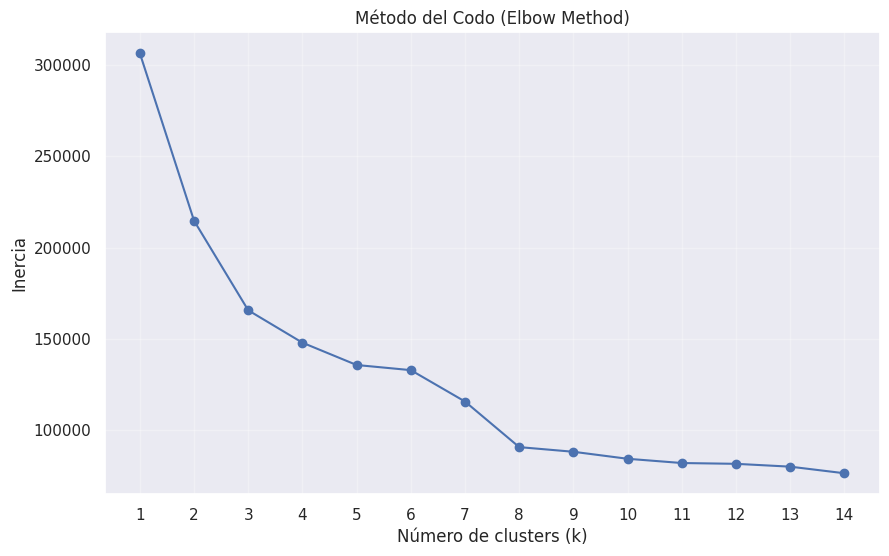

In [14]:
plt.figure(figsize=(10,6))

plt.plot(k_values, inercia, marker="o")

plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

# **Reducción de dimensionalidad**

In [15]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [16]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Análisis detallado con PCA**

In [18]:
from sklearn.datasets import load_wine
import pandas as pd

dataset = load_wine()

wine = pd.DataFrame(dataset.data, columns=dataset.feature_names)
wine["wine_class"] = dataset.target

In [19]:
X = wine.drop(columns="wine_class")
y = wine["wine_class"]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

In [22]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PCA completo (todas las componentes)
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

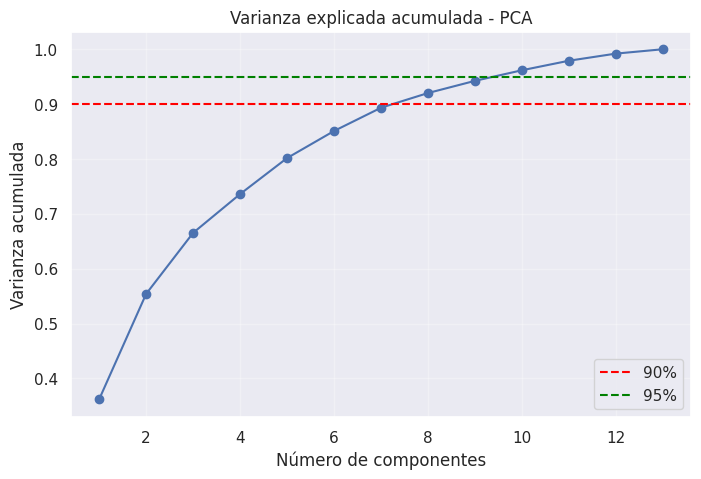

In [23]:
varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(varianza)+1), varianza_acumulada, marker="o")

plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.axhline(0.95, color="green", linestyle="--", label="95%")

plt.title("Varianza explicada acumulada - PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [24]:
df_pca = pd.DataFrame(
    X_pca_full,
    columns=[f"PC{i+1}" for i in range(X_pca_full.shape[1])]
)

df_pca["wine_class"] = y

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,wine_class
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,-0.451563,0.540810,-0.066239,0
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,-0.142657,0.388238,0.003637,0
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,-0.286673,0.000584,0.021717,0
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,0.759584,-0.242020,-0.369484,0
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,-0.525945,-0.216664,-0.079364,0


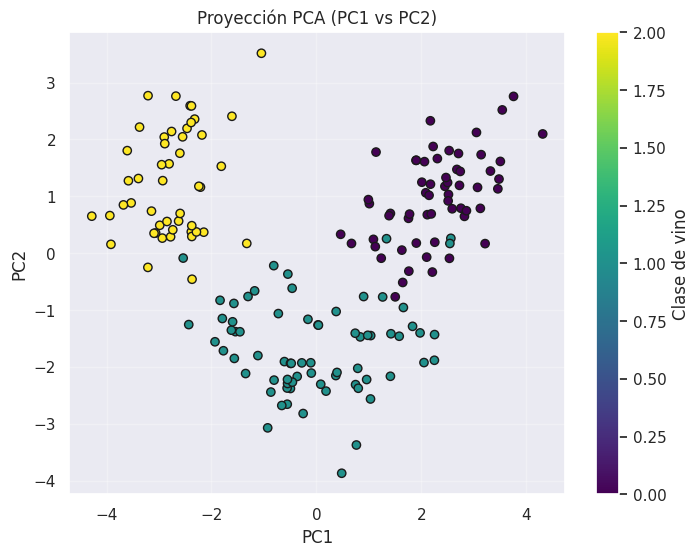

In [25]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.title("Proyección PCA (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter, label="Clase de vino")
plt.grid(alpha=0.3)

plt.show()

In [26]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=X.columns
)

loadings.iloc[:, :3]  # primeras 3 componentes

,PC1,PC2,PC3
alcohol,0.144329,0.483652,-0.207383
malic_acid,-0.245188,0.224931,0.089013
ash,-0.002051,0.316069,0.626224
alcalinity_of_ash,-0.239320,-0.010591,0.612080
magnesium,0.141992,0.299634,0.130757
total_phenols,0.394661,0.065040,0.146179
flavanoids,0.422934,-0.003360,0.150682
nonflavanoid_phenols,-0.298533,0.028779,0.170368
proanthocyanins,0.313429,0.039302,0.149454
color_intensity,-0.088617,0.529996,-0.137306


In [27]:
loadings["PC1"].sort_values(ascending=False)

,PC1
flavanoids,0.422934
total_phenols,0.394661
od280/od315_of_diluted_wines,0.376167
proanthocyanins,0.313429
hue,0.296715
proline,0.286752
alcohol,0.144329
magnesium,0.141992
ash,-0.002051
color_intensity,-0.088617


In [28]:
loadings["PC2"].sort_values(ascending=False)

,PC2
color_intensity,0.529996
alcohol,0.483652
proline,0.364903
ash,0.316069
magnesium,0.299634
malic_acid,0.224931
total_phenols,0.065040
proanthocyanins,0.039302
nonflavanoid_phenols,0.028779
flavanoids,-0.003360


**Análisis detallado con t-SNE**

In [29]:
from sklearn.preprocessing import StandardScaler

X = wine.drop(columns="wine_class")
y = wine["wine_class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

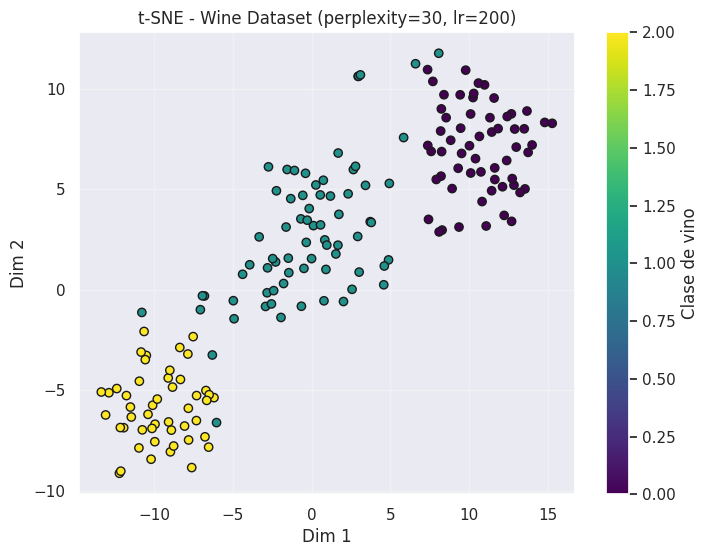

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.title("t-SNE - Wine Dataset (perplexity=30, lr=200)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Clase de vino")

plt.grid(alpha=0.3)
plt.show()

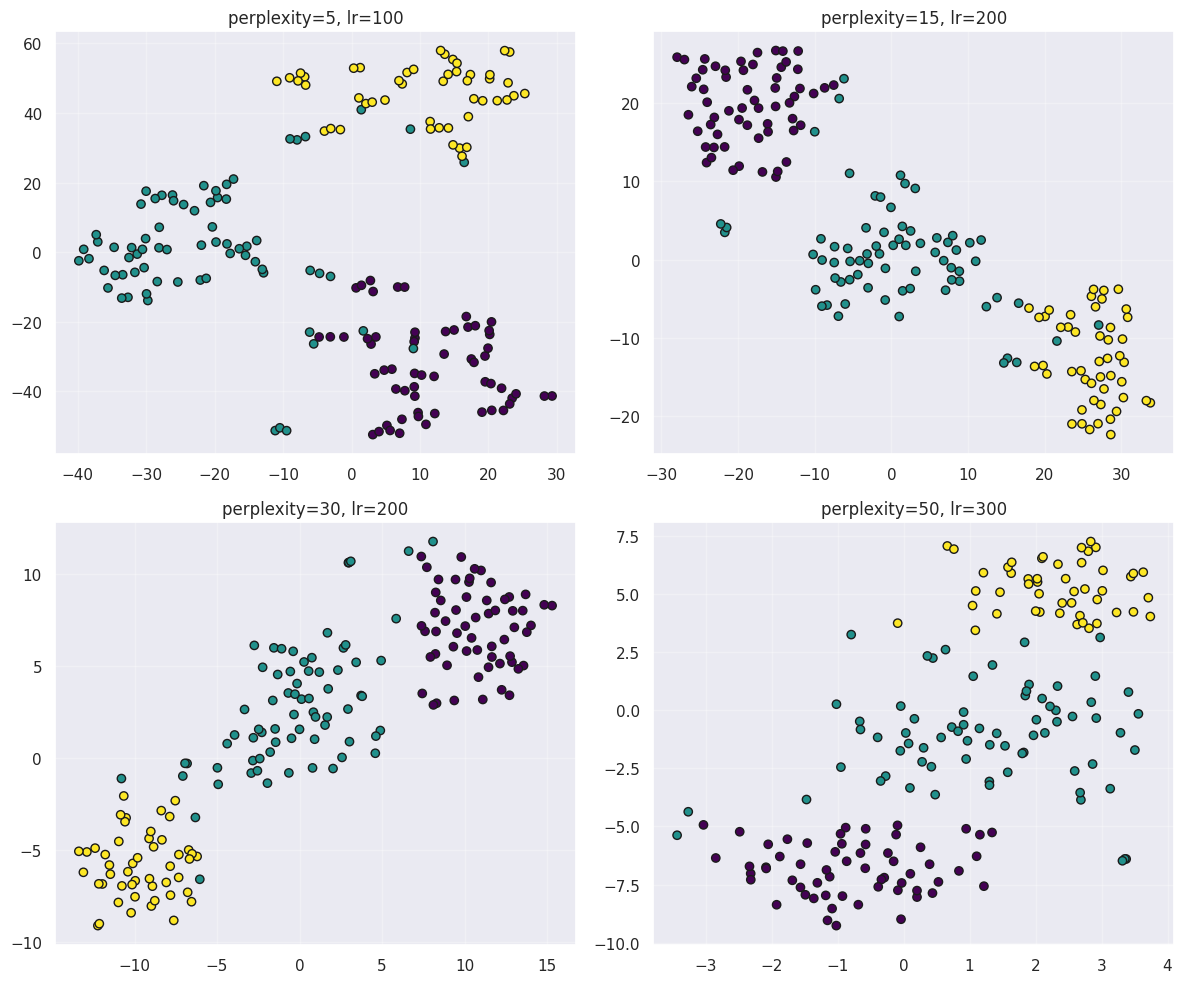

In [32]:
configs = [
    (5, 100),
    (15, 200),
    (30, 200),
    (50, 300)
]

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()

for i, (perp, lr) in enumerate(configs):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate=lr,
        random_state=42
    )

    X_t = tsne.fit_transform(X_scaled)

    axes[i].scatter(X_t[:,0], X_t[:,1], c=y, cmap="viridis", edgecolor="k")
    axes[i].set_title(f"perplexity={perp}, lr={lr}")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Comparación entre PCA y t-SNE**

PCA: enfoque lineal

El Análisis de Componentes Principales (PCA) es una técnica lineal que busca proyectar los datos en nuevas dimensiones que maximicen la varianza explicada. Su principal fortaleza radica en su capacidad para resumir la información del dataset en un menor número de variables manteniendo la estructura global de los datos.

En este caso, PCA permite observar una separación parcial entre las tres clases de vino, lo que indica que una proporción importante de la varianza está asociada a diferencias entre clases. Sin embargo, se aprecia cierta superposición, lo que sugiere que las relaciones entre variables no son completamente lineales.

Entre sus principales ventajas destacan:

Alta interpretabilidad de los componentes.
Conservación de la estructura global del dataset.
Utilidad como etapa de preprocesamiento para modelos de machine learning.
Reducción de dimensionalidad eficiente y rápida.

No obstante, su principal limitación es que no es capaz de capturar relaciones no lineales complejas presentes en los datos.

t-SNE: enfoque no lineal

t-SNE (t-distributed Stochastic Neighbor Embedding) es una técnica no lineal que se enfoca en preservar las relaciones locales entre observaciones. A diferencia de PCA, no busca maximizar varianza, sino mantener la similitud entre puntos vecinos.

En este análisis, t-SNE muestra una separación más clara entre las tres clases de vino, formando agrupaciones bien definidas. Esto indica que existen estructuras no lineales en los datos que PCA no logra capturar.

Entre sus ventajas se encuentran:

Excelente capacidad de visualización de clusters.
Captura relaciones no lineales complejas.
Muy útil para exploración de datos.

Sin embargo, presenta limitaciones importantes:

Baja interpretabilidad de las dimensiones resultantes.
Alta sensibilidad a hiperparámetros como perplexity y learning rate.
No es adecuado como método de preprocesamiento para modelos predictivos.

Comparación general

Ambos métodos cumplen roles complementarios. PCA es más adecuado cuando se busca interpretación, reducción de dimensionalidad previa al modelado o comprensión global de la estructura de los datos. En cambio, t-SNE es más apropiado para exploración visual y detección de patrones locales o agrupaciones.

En este caso, PCA permite entender la contribución de las variables químicas a la variabilidad total del dataset, mientras que t-SNE permite visualizar de manera más clara la separación entre las clases de vino.

Importancia de la reducción de dimensionalidad

La reducción de dimensionalidad es una herramienta fundamental en datasets de alta dimensión como Wine, ya que permite:

Visualizar patrones ocultos que no son evidentes en el espacio original.
Reducir el ruido y la redundancia de variables.
Mejorar la comprensión estructural de los datos.
Facilitar la comunicación de resultados mediante representaciones bidimensionales o tridimensionales.

En conjunto, estas técnicas permiten transformar un problema complejo en uno más interpretable, sin perder información relevante para el análisis.